In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import transformers as transform
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [4]:
data_path = "flight_data.csv"
target_col = "Delay"
test_size = 0.2
random_seed = 42


In [5]:
def load(path):
    df = pd.read_csv(path)
    df = df.applymap(lambda x: x.decode('utf-8') 
                     if isinstance(x, bytes)
                     else x)
    print(df.shape)
    print(df.head())
    return df

def add_features(df):
    df = df.copy()
    
    df['dep_hour'] = df['Time'] // 100
    df['morning'] = ((df['dep_hour'] >= 5) & (df['dep_hour'] < 12)).astype(int)
    df['evening'] = ((df['dep_hour'] >= 17) & (df['dep_hour'] < 21)).astype(int)
    df['weekend'] = df['DayOfWeek'].isin([6,7]).astype(int)
    df['long_flight'] = (df['Length'] > 180).astype(int)
    df['route'] = df['AirportFrom'] + "_" + df['AirportTo']
    df['airline_delay_rate'] = df.groupby('Airline')['Delay'].transform('mean')
    df['route_delay_rate'] = df.groupby('route')['Delay'].transform('mean')
    df['hour_delay_rate'] = df.groupby('dep_hour')['Delay'].transform('mean')
    df['frequency_of_route'] = df.groupby('route')['route'].transform('count')
    df['peak_hour'] = df['dep_hour'].apply(lambda x: 1 if 7 <=x <=10 or 16 <= x <= 20 else 0)

    return df

def encode(df):
    df = pd.get_dummies(
        df, 
        columns = ['Airline', 'AirportFrom', 'AirportTo', 'route'],
        drop_first = True
    )
    print(df.shape)
    return df

def split_scale(df):
    X = df.drop(columns=[target_col])
    Y = df[target_col]
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y,test_size=test_size, random_state=random_seed
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, Y_train, Y_test

In [6]:
def train_models(X_train, X_test, Y_train, Y_test):
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, Y_train)
    Y_pred_lr = lr.predict(X_test)
    Y_prob_lr = lr.predict_proba(X_test)[:,1]

    print("Logistic Regression")
    print("Accuracy:", accuracy_score(Y_test, Y_pred_lr))
    print("Precision:", precision_score(Y_test, Y_pred_lr))
    print("Recall:", recall_score(Y_test, Y_pred_lr))
    print("F1:", f1_score(Y_test, Y_pred_lr))
    print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_lr))

    dt = DecisionTreeClassifier(max_depth=5)
    dt.fit(X_train, Y_train)
    Y_pred_dt = dt.predict(X_test)
    Y_prob_dt = dt.predict_proba(X_test)[:,1]

    print("Decision Tree")
    print("Accuracy:", accuracy_score(Y_test, Y_pred_dt))
    print("Precision:", precision_score(Y_test, Y_pred_dt))
    print("Recall:", recall_score(Y_test, Y_pred_dt))
    print("F1:", f1_score(Y_test, Y_pred_dt))
    print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_dt))

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, Y_train)
    Y_pred_rf = rf.predict(X_test)
    Y_prob_rf = rf.predict_proba(X_test)[:,1]

    print("Random Forest")
    print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))
    print("Precision:", precision_score(Y_test, Y_pred_rf))
    print("Recall:", recall_score(Y_test, Y_pred_rf))
    print("F1:", f1_score(Y_test, Y_pred_rf))
    print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_rf))

    nn = MLPClassifier(hidden_layer_sizes=(32,), max_iter=100, random_state=42)
    nn.fit(X_train,Y_train)
    Y_pred_nn = nn.predict(X_test)
    Y_prob_nn = nn.predict_proba(X_test)[:,1]

    print("Neural Network")
    print("Accuracy:", accuracy_score(Y_test, Y_pred_nn))
    print("Precision:", precision_score(Y_test, Y_pred_nn))
    print("Recall:", recall_score(Y_test, Y_pred_nn))
    print("F1:", f1_score(Y_test, Y_pred_nn))
    print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_nn))



In [7]:
df = load(data_path)
df = add_features(df)
df = encode(df)

X_train, X_test, Y_train, Y_test = split_scale(df)

train_models(X_train, X_test, Y_train, Y_test)

/var/folders/2t/h_cypqr94zx0kjmx1phwr9h40000gn/T/ipykernel_56251/979075951.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8')


(26969, 8)
  Airline  Flight AirportFrom AirportTo  DayOfWeek   Time  Length  Delay
0      OO    4492         GJT       SLC          6  785.0    56.0      0
1      EV    5364         MGM       MEM          6  375.0    76.0      0
2      FL    1016         BOS       MCO          7  703.0   205.0      0
3      F9     231         BNA       DEN          5  880.0   173.0      0
4      AS     662         SEA       DFW          5  730.0   230.0      0
(26969, 4418)
Logistic Regression
Accuracy: 0.6281053021876158
Precision: 0.5851851851851851
Recall: 0.5324347093513058
F1: 0.5575650639611822
ROC-AUC: 0.6591665643812382
Decision Tree
Accuracy: 0.7041156840934372
Precision: 0.6916256157635468
Recall: 0.5914069081718618
F1: 0.6376021798365122
ROC-AUC: 0.7786547280974352
Random Forest
Accuracy: 0.6416388579903597
Precision: 0.6016597510373444
Recall: 0.5497051390058972
F1: 0.5745102355271847
ROC-AUC: 0.7001856480525785
Neural Network
Accuracy: 0.5939933259176863
Precision: 0.5396893874029336
Reca

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


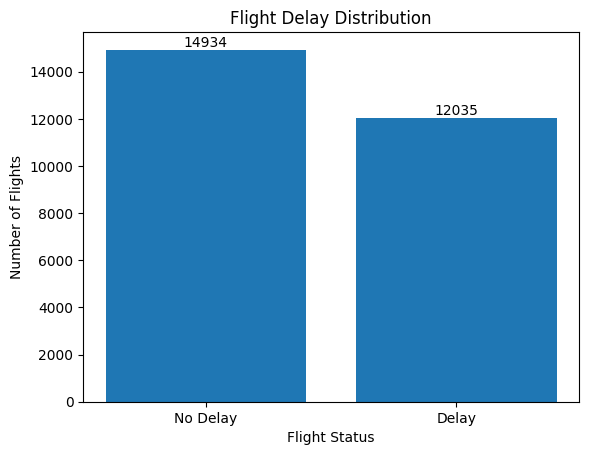

In [8]:
counts = df['Delay'].value_counts().sort_index()

plt.figure()
plt.bar(['No Delay', 'Delay'], counts.values)
plt.title("Flight Delay Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

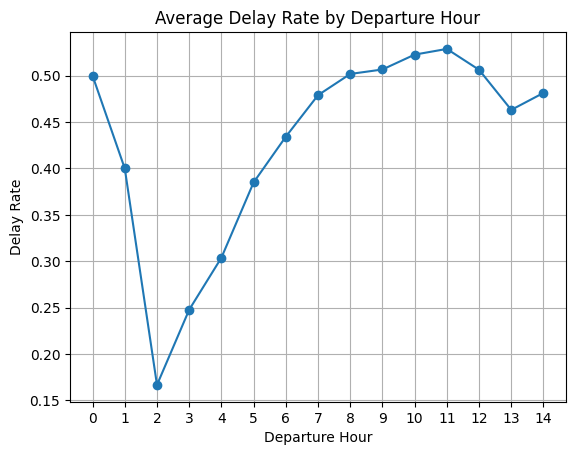

In [9]:
delay_by_hour = df.groupby('dep_hour')['Delay'].mean()

plt.figure()
plt.plot(delay_by_hour.index, delay_by_hour.values, marker='o')

plt.title("Average Delay Rate by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate")

plt.xticks(range(int(delay_by_hour.index.min()), int(delay_by_hour.index.max())+1))
plt.grid()

plt.show()

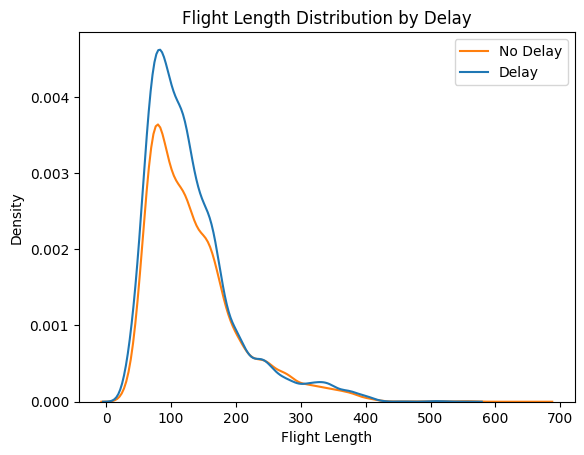

In [12]:

plt.figure()

sns.kdeplot(data=df, x='Length', hue='Delay')

plt.title("Flight Length Distribution by Delay")
plt.xlabel("Flight Length")
plt.legend(["No Delay", "Delay"])
plt.show()

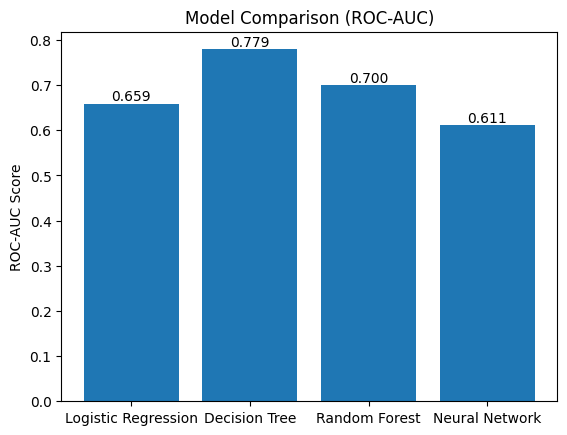

In [13]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Neural Network"],
    "ROC-AUC": [0.659, 0.779, 0.700, 0.611]
}

df_results = pd.DataFrame(results)

plt.figure()
bars = plt.bar(df_results["Model"], df_results["ROC-AUC"])

plt.title("Model Comparison (ROC-AUC)")
plt.ylabel("ROC-AUC Score")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')

plt.show()

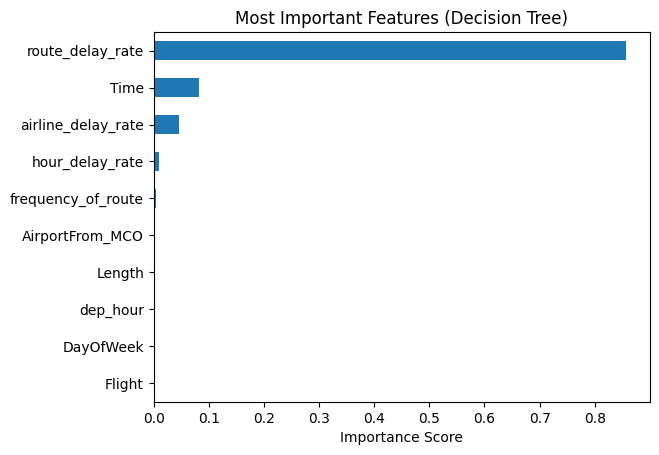

In [14]:
X_columns = df.drop(columns=[target_col]).columns
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, Y_train)
feature_importance = pd.Series(dt.feature_importances_, index=X_columns)
top_features = feature_importance.nlargest(10).sort_values()

plt.figure()
top_features.plot(kind='barh')

plt.title("Most Important Features (Decision Tree)")
plt.xlabel("Importance Score")
plt.show()

In [28]:
def model_comparison():

    df_base = load(data_path)
    df_base = pd.get_dummies(df_base, columns=['Airline','AirportFrom','AirportTo'], drop_first=True)
    X_train_b, X_test_b, Y_train_b, Y_test_b = split_scale(df_base)


    df_eng = load(data_path)
    df_eng = add_features(df_eng)
    df_eng = encode(df_eng)
    X_train_e, X_test_e, Y_train_e, Y_test_e = split_scale(df_eng)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(max_depth=5),
        "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
        "Neural Network": MLPClassifier(hidden_layer_sizes=(32,), max_iter=100, random_state=42)
    }

    print(f"{"Model":<22} {"Metric":<10} {"Without":>10} {"With":>10}")
    print("-" * 55)

    for name, model in models.items():
        for X_tr, X_te, label in [(X_train_b, X_test_b, 'base'), (X_train_e, X_test_e, 'eng')]:
            model.fit(X_tr, Y_tr := Y_train_b if label=='base' else Y_train_e)
            yp = model.predict(X_te)
            yprob = model.predict_proba(X_te)[:,1]

            if label == 'base':
                b_acc, b_f1, b_auc = accuracy_score(Y_test_b, yp), f1_score(Y_test_b, yp), roc_auc_score(Y_test_b, yprob)
            else:
                e_acc, e_f1, e_auc = accuracy_score(Y_test_e, yp), f1_score(Y_test_e, yp), roc_auc_score(Y_test_e, yprob)

        for metric, b, e in [
            ("Accuracy", b_acc, e_acc),
            ("F1", b_f1, e_f1),
            ("ROC-AUC", b_auc, e_auc)
        ]:
            print(f"{name:<22} {metric:<10} {b:>10.4f} {e:>10.4f}")

model_comparison()

/var/folders/2t/h_cypqr94zx0kjmx1phwr9h40000gn/T/ipykernel_56251/979075951.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8')


(26969, 8)
  Airline  Flight AirportFrom AirportTo  DayOfWeek   Time  Length  Delay
0      OO    4492         GJT       SLC          6  785.0    56.0      0
1      EV    5364         MGM       MEM          6  375.0    76.0      0
2      FL    1016         BOS       MCO          7  703.0   205.0      0
3      F9     231         BNA       DEN          5  880.0   173.0      0
4      AS     662         SEA       DFW          5  730.0   230.0      0


/var/folders/2t/h_cypqr94zx0kjmx1phwr9h40000gn/T/ipykernel_56251/979075951.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode('utf-8')


(26969, 8)
  Airline  Flight AirportFrom AirportTo  DayOfWeek   Time  Length  Delay
0      OO    4492         GJT       SLC          6  785.0    56.0      0
1      EV    5364         MGM       MEM          6  375.0    76.0      0
2      FL    1016         BOS       MCO          7  703.0   205.0      0
3      F9     231         BNA       DEN          5  880.0   173.0      0
4      AS     662         SEA       DFW          5  730.0   230.0      0
(26969, 4418)
Model                  Metric        Without       With
-------------------------------------------------------
Logistic Regression    Accuracy       0.6385     0.6281
Logistic Regression    F1             0.5407     0.5576
Logistic Regression    ROC-AUC        0.6782     0.6592
Decision Tree          Accuracy       0.6339     0.7041
Decision Tree          F1             0.5019     0.6376
Decision Tree          ROC-AUC        0.6579     0.7787
Random Forest          Accuracy       0.6322     0.6433
Random Forest          F1        

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network         Accuracy       0.6135     0.5940
Neural Network         F1             0.5569     0.5332
Neural Network         ROC-AUC        0.6432     0.6112


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
